# **Ball Tree KNN**

## **Project:**

- Large Scale Product Recommendation System

## **Problem Statement:**

- Build a fast recommendation engine for high-dimensional customer-product data.

In [22]:
# Step No 1 : Importing the required libraries 

# Import Numerical Library
import numpy as np 

# Import Data Manipulation Library
import pandas as pd 

# Import Data Visualization Libraries 
import matplotlib.pyplot as plt 

# Import seaborn library 
import seaborn as sns 

# Import train test split library
from sklearn.model_selection import train_test_split

# Import Standard Scaler Library
from sklearn.preprocessing import StandardScaler 

# Import KNN Classifier 
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics 
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix


In [23]:
# Step No 2 : Loading the dataset
# Load the dataset 
df = pd.read_csv("product_recommendation_dataset_1000.csv")

In [24]:
# Step No 3 : Data Exploration and Preprocessing 

# Display the first 5 rows of the dataset 
print(df.head())

# Display the shape of the dataset 
print(df.shape)

# Display the summary statistics of the dataset 
print(df.describe())

# Display the information about the dataset 
print(df.info())

   UserID  ProductID  Price  Rating  PurchaseCount  Recommended
0     522        205   8396     4.4             12            1
1     738        216  43089     4.8             17            1
2     741        253  47456     4.9             23            1
3     661        203  28682     3.7             14            1
4     412        357  18227     2.8             21            1
(1000, 6)
            UserID    ProductID          Price       Rating  PurchaseCount  \
count  1000.000000  1000.000000    1000.000000  1000.000000    1000.000000   
mean    500.500000   301.081000   32348.476000     3.723191      18.403000   
std     288.819436   114.439026   63592.401346     0.745671      25.764557   
min       1.000000   100.000000     655.000000     1.301251       1.000000   
25%     250.750000   206.000000   13047.250000     3.100000       8.000000   
50%     500.500000   300.000000   25811.500000     3.700000      16.000000   
75%     750.250000   401.000000   38164.500000     4.400000 

In [25]:
# Step No 4 : Data Cleaning and handling missing values 

# Check for missing values 
print(df.isnull().sum())

# Check for duplicate values 
print(df.duplicated().sum())

# Remove duplicate values 
print(df.drop_duplicates(inplace=True))

UserID           0
ProductID        0
Price            0
Rating           0
PurchaseCount    0
Recommended      0
dtype: int64
0
None


In [26]:
# Step No 5 : Features and Targer variable selection
# Define input features 
X = df[[
    "Price",
    "Rating",
    "PurchaseCount"
]]

# Define targer variable 
y = df["Recommended"]

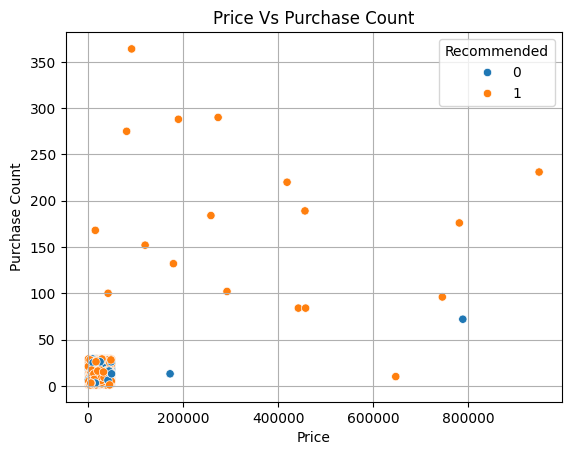

In [27]:
# Step No 6 : Visualization of the dataset 
sns.scatterplot(
    x="Price",
    y="PurchaseCount",
    hue="Recommended",
    data=df
)
# Set Plot Title 
plt.title("Price Vs Purchase Count")

# Set x-axis label
plt.xlabel("Price")

# Set y-axis label 
plt.ylabel("Purchase Count")

# Enable Grid 
plt.grid()

# Save the Plot 
plt.savefig("images/price Vs purchase Count(Ball Tree KNN)")

# Show the Plot 
plt.show()

In [28]:
# Step No 7 : Split dataset 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42
)

In [29]:
# Step No 8 : Create scaler object 
scaler = StandardScaler()


In [30]:
# Step No 9 : Scaling Trainin and Testing data 

# Scale training data 
X_train = scaler.fit_transform(X_train)

# Scale testing data 
X_test = scaler.transform(X_test)

In [31]:
# Step No 10 : Create Ball Tree KNN Classifier Object 
model = KNeighborsClassifier(
    n_neighbors= 5 , 
    algorithm = "ball_tree"
)

# n_neighbors : nearest products
# algorithm : ball tree search

In [32]:
# Step No 11 : Train the model 
model.fit(X_train ,y_train)

KNeighborsClassifier(algorithm='ball_tree')

In [33]:
# Step No 12 : Predict Recommendations and display predictions
y_pred = model.predict(X_test)

# Display the predicted values 
print("Predicted Recommendations : ")
print(y_pred)

Predicted Recommendations : 
[1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1
 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]


In [34]:
# Step No 13 : Evaluate the model 

# Calculate accuracy score 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Calculate classification report 
print("Classification Report : ")
print(classification_report(y_test , y_pred))

# Calculate Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

Accuracy Score : 
0.75
Classification Report : 
              precision    recall  f1-score   support

           0       0.20      0.07      0.11        41
           1       0.79      0.92      0.85       159

    accuracy                           0.75       200
   macro avg       0.50      0.50      0.48       200
weighted avg       0.67      0.75      0.70       200

Confusion Matrix : 
[[  3  38]
 [ 12 147]]


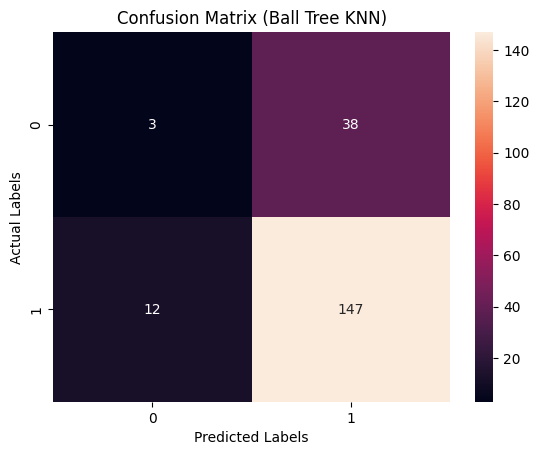

In [35]:
# Step No 14 : Plot Confusion Matrix 
sns.heatmap(
    confusion_matrix(y_test , y_pred),
    annot=True,
    fmt = "d"
)

# Set Plot Title 
plt.title("Confusion Matrix (Ball Tree KNN)")

# Set x-axis label 
plt.xlabel("Predicted Labels")

# Set y-axis label 
plt.ylabel("Actual Labels")

# Save the Plot 
plt.savefig("images/Confusion Matrix(Ball Tree KNN).png")

# Show the Plot 
plt.show()

In [36]:
# Step No 15 : User Input for Product Recommendation

# Take Price input 
price = float(input("Enter the Price of the Product : "))

# Take Rating Input 
rating = float(input("Enter the Rating of the Product : "))

# Take Purchase Count Input
purchase_count = int(input("Enter the Purchase Count of the Product : "))


In [37]:
# Step No 16 : Create user dataframe 
user_data = pd.DataFrame({
    "Price": [price],
    "Rating": [rating],
    "PurchaseCount": [purchase_count]
})

In [38]:
# Step No 17 : Scale the user input data 
user_data = scaler.transform(user_data)


In [39]:
# Step No 18 : Predict recommendation for user input 
result = model.predict(user_data)

In [40]:
# Step No 19 : Display the recommendation result 
if result[0] == 1 :
    print("Product is Recommended")
else:
    print("Product is Not Recommended")

Product is Recommended
